# F1 2026 Barcelona Grand Prix — Race Prediction Model
**Author:** Amit | ML Intern Project  
**Date:** June 2026  
**Target Race:** Circuit de Barcelona-Catalunya | June 14, 2026  

---
### Objective
Predict the finishing order for the 2026 Spanish Grand Prix using:
- Historical Barcelona race results (2021–2025)
- 2026 season form data
- Qualifying performance
- Sprint race results (2026)

### Model
Ensemble of **XGBoost** + **Random Forest** regressors trained on 5 years of Barcelona data.


## Section 1: Imports & Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
from xgboost import XGBRegressor

print("Libraries loaded successfully")


Libraries loaded successfully


## Section 2: Load & Clean Data

In [5]:
BASE = 'C:\Wind BReaker\Test_site\Data'  # Change this to your local path

RACE_FILES = {
    2021: f'{BASE}/formula1_2021season_raceResults.csv',
    2022: f'{BASE}/Formula1_2022season_raceResults.csv',
    2023: f'{BASE}/Formula1_2023season_raceResults.csv',
    2024: f'{BASE}/Formula1_2024season_raceResults.csv',
    2025: f'{BASE}/Formula1_2025Season_RaceResults.csv',
    2026: f'{BASE}/Formula1_2026Season_RaceResults.csv',
}

QUAL_FILES = {
    2022: f'{BASE}/Formula1_2022season_qualifyingResults.csv',
    2023: f'{BASE}/Formula1_2023season_qualifyingResults.csv',
    2024: f'{BASE}/Formula1_2024season_qualifyingResults.csv',
    2025: f'{BASE}/Formula1_2025Season_QualifyingResults.csv',
    2026: f'{BASE}/Formula1_2026Season_QualifyingResults.csv',
}

def clean_position(pos):
    """Convert position to numeric. NC/DQ → 20 (last place proxy)"""
    try:
        return int(pos)
    except:
        return 20

def load_all_races():
    frames = []
    for yr, path in RACE_FILES.items():
        df = pd.read_csv(path)
        df['Season'] = yr
        df['Position_Clean'] = df['Position'].apply(clean_position)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

def load_all_qualifying():
    frames = []
    for yr, path in QUAL_FILES.items():
        df = pd.read_csv(path)
        df['Season'] = yr
        df['Position'] = pd.to_numeric(df['Position'], errors='coerce').fillna(20)
        frames.append(df)
    return pd.concat(frames, ignore_index=True)

all_races = load_all_races()
all_qual  = load_all_qualifying()
sprint_2026 = pd.read_csv(f'{BASE}/Formula1_2026Season_SprintResults.csv')

print(f"Total race rows: {len(all_races)}")
print(f"Seasons: {sorted(all_races['Season'].unique())}")


Total race rows: 2410
Seasons: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025), np.int64(2026)]


## Section 3: Extract Barcelona Data

Barcelona is labeled **'Spain'** in this dataset across all seasons.

In [6]:
barcelona_races = all_races[all_races['Track'] == 'Spain'].copy()

print(f"Barcelona race entries: {len(barcelona_races)}")
print(f"Seasons with Barcelona data: {sorted(barcelona_races['Season'].unique())}")

# Show all Barcelona results
barcelona_races[['Season','Driver','Team','Position_Clean']].sort_values(['Season','Position_Clean'])


Barcelona race entries: 99
Seasons with Barcelona data: [np.int64(2021), np.int64(2022), np.int64(2023), np.int64(2024), np.int64(2025)]


,Season,Driver,Team,Position_Clean
60,2021,Lewis Hamilton,Mercedes,1
61,2021,Max Verstappen,Red Bull Racing Honda,2
62,2021,Valtteri Bottas,Mercedes,3
63,2021,Charles Leclerc,Ferrari,4
64,2021,Sergio Perez,Red Bull Racing Honda,5
...,...,...,...,...
1973,2025,Franco Colapinto,Alpine Renault,15
1974,2025,Esteban Ocon,Haas Ferrari,16
1975,2025,Oliver Bearman,Haas Ferrari,17
1976,2025,Kimi Antonelli,Mercedes,20


## Section 4: Feature Engineering

For each 2026 driver, we build these features:

| Feature | Description |
|---|---|
| `barcelona_avg_finish` | Historical avg finish at Barcelona |
| `barcelona_appearances` | Number of times raced at Barcelona |
| `barcelona_best_finish` | Best ever finish at Barcelona |
| `avg_finish_2025` | Full 2025 season avg position |
| `avg_finish_2026` | 2026 season avg so far |
| `sprint_points_2026` | Sprint points in 2026 (pace indicator) |
| `sprint_avg_position` | Avg sprint finish in 2026 |
| `avg_grid_delta` | Avg positions gained/lost from grid |
| `dnf_rate` | DNF rate (reliability risk) |
| `team_avg_finish_2026` | Team's avg finish in 2026 (car quality) |
| `avg_qual_position` | Avg qualifying position 2025-2026 |


In [7]:
drivers_2026 = all_races[all_races['Season'] == 2026]['Driver'].unique()
feature_rows = []

for driver in drivers_2026:
    row = {'Driver': driver}

    bcn_hist = barcelona_races[barcelona_races['Driver'] == driver]
    row['barcelona_avg_finish']  = bcn_hist['Position_Clean'].mean() if len(bcn_hist) > 0 else 15.0
    row['barcelona_appearances'] = len(bcn_hist)
    row['barcelona_best_finish'] = bcn_hist['Position_Clean'].min() if len(bcn_hist) > 0 else 20

    form_2025 = all_races[(all_races['Driver'] == driver) & (all_races['Season'] == 2025)]
    row['avg_finish_2025'] = form_2025['Position_Clean'].mean() if len(form_2025) > 0 else 15.0

    form_2026 = all_races[(all_races['Driver'] == driver) & (all_races['Season'] == 2026)]
    row['avg_finish_2026'] = form_2026['Position_Clean'].mean() if len(form_2026) > 0 else 15.0
    row['races_2026'] = len(form_2026)

    sp = sprint_2026[sprint_2026['Driver'] == driver]
    row['sprint_points_2026']   = sp['Points'].sum() if len(sp) > 0 else 0
    row['sprint_avg_position']  = sp['Position'].apply(clean_position).mean() if len(sp) > 0 else 15.0

    driver_races = all_races[
        (all_races['Driver'] == driver) & (all_races['Season'].isin([2024, 2025, 2026]))
    ].copy()
    driver_races['grid_delta'] = driver_races['Starting Grid'] - driver_races['Position_Clean']
    row['avg_grid_delta'] = driver_races['grid_delta'].mean() if len(driver_races) > 0 else 0.0

    all_dr = all_races[(all_races['Driver'] == driver) & (all_races['Season'].isin([2024, 2025, 2026]))]
    row['dnf_rate'] = (all_dr['Position'] == 'NC').sum() / len(all_dr) if len(all_dr) > 0 else 0.1

    driver_team = all_races[(all_races['Driver'] == driver) & (all_races['Season'] == 2026)]['Team'].mode()
    if len(driver_team) > 0:
        team = driver_team.iloc[0]
        team_races = all_races[(all_races['Team'] == team) & (all_races['Season'] == 2026)]
        row['team_avg_finish_2026'] = team_races['Position_Clean'].mean()
        row['Team'] = team
    else:
        row['team_avg_finish_2026'] = 15.0
        row['Team'] = 'Unknown'

    qual_recent = all_qual[(all_qual['Driver'] == driver) & (all_qual['Season'].isin([2025, 2026]))]
    row['avg_qual_position'] = qual_recent['Position'].mean() if len(qual_recent) > 0 else 15.0

    feature_rows.append(row)

features_df = pd.DataFrame(feature_rows)
print(f"Feature matrix: {features_df.shape}")
features_df[['Driver','barcelona_avg_finish','avg_finish_2026','sprint_points_2026','avg_qual_position']]


Feature matrix: (22, 14)


,Driver,barcelona_avg_finish,avg_finish_2026,sprint_points_2026,avg_qual_position
0,George Russell,5.600000,7.166667,21,4.066667
1,Kimi Antonelli,20.000000,1.166667,13,7.133333
2,Charles Leclerc,8.600000,7.000000,17,5.266667
3,Lewis Hamilton,3.400000,3.833333,11,8.233333
4,Lando Norris,7.400000,12.000000,20,3.433333
5,Max Verstappen,3.000000,10.333333,6,3.896552
6,Oliver Bearman,17.000000,12.166667,1,13.933333
7,Arvid Lindblad,15.000000,12.333333,1,12.333333
8,Gabriel Bortoleto,12.000000,13.000000,0,14.000000
9,Pierre Gasly,10.000000,9.666667,1,12.733333


## Section 5: Build Training Dataset

We train on each Barcelona race from 2021–2025.  
For each race entry, features are built using **only data available before that race** (no data leakage).


In [8]:
train_rows = []

for _, race_row in barcelona_races.iterrows():
    season = race_row['Season']
    driver = race_row['Driver']
    actual_position = race_row['Position_Clean']

    bcn_before = barcelona_races[
        (barcelona_races['Driver'] == driver) & (barcelona_races['Season'] < season)
    ]
    prior_season = all_races[(all_races['Driver'] == driver) & (all_races['Season'] == season - 1)]
    prior_qual   = all_qual[(all_qual['Driver'] == driver) & (all_qual['Season'] == season - 1)]
    cur_season   = all_races[
        (all_races['Driver'] == driver) & (all_races['Season'] == season) & (all_races['Track'] != 'Spain')
    ]

    t = {
        'actual_position':        actual_position,
        'barcelona_avg_finish':   bcn_before['Position_Clean'].mean() if len(bcn_before) > 0 else 15.0,
        'barcelona_appearances':  len(bcn_before),
        'barcelona_best_finish':  bcn_before['Position_Clean'].min() if len(bcn_before) > 0 else 20,
        'avg_finish_prior_season':prior_season['Position_Clean'].mean() if len(prior_season) > 0 else 15.0,
        'avg_qual_position':      prior_qual['Position'].mean() if len(prior_qual) > 0 else 15.0,
        'current_season_avg':     cur_season['Position_Clean'].mean() if len(cur_season) > 0 else 15.0,
        'avg_grid_delta':         (cur_season['Starting Grid'] - cur_season['Position_Clean']).mean() if len(cur_season) > 0 else 0.0,
        'dnf_rate':               (prior_season['Position'] == 'NC').sum() / len(prior_season) if len(prior_season) > 0 else 0.1,
        'team_avg_finish':        cur_season['Position_Clean'].mean() if len(cur_season) > 0 else 15.0,
    }
    train_rows.append(t)

train_df = pd.DataFrame(train_rows)
print(f"Training samples: {len(train_df)}")
train_df.describe()


Training samples: 99


,actual_position,barcelona_avg_finish,barcelona_appearances,barcelona_best_finish,avg_finish_prior_season,avg_qual_position,current_season_avg,avg_grid_delta,dnf_rate,team_avg_finish
count,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000,99.000000
mean,10.444444,11.650673,1.444444,12.080808,11.448163,12.282619,10.653767,-0.163263,0.107912,10.653767
std,5.806791,4.899134,1.349393,7.240302,3.932618,4.015108,3.968537,1.443818,0.067379,3.968537
min,1.000000,1.000000,0.000000,1.000000,1.272727,2.590909,1.285714,-3.904762,0.000000,1.285714
25%,5.500000,8.250000,0.000000,5.500000,8.000000,10.272727,7.394410,-1.119048,0.085145,7.394410
50%,10.000000,14.000000,1.000000,11.000000,12.727273,15.000000,11.652174,-0.285714,0.100000,11.652174
75%,15.000000,15.000000,2.000000,20.000000,15.000000,15.000000,13.496164,0.793651,0.136364,13.496164
max,20.000000,20.000000,4.000000,20.000000,16.954545,17.500000,18.380952,4.173913,0.333333,18.380952


## Section 6: Train Model

In [9]:
FEATURE_COLS = [
    'barcelona_avg_finish', 'barcelona_appearances', 'barcelona_best_finish',
    'avg_finish_prior_season', 'avg_qual_position', 'current_season_avg',
    'avg_grid_delta', 'dnf_rate', 'team_avg_finish'
]

X_train = train_df[FEATURE_COLS].fillna(15.0)
y_train = train_df['actual_position']

# XGBoost
xgb = XGBRegressor(n_estimators=200, max_depth=3, learning_rate=0.05,
                   subsample=0.8, colsample_bytree=0.8, random_state=42, verbosity=0)
cv_xgb = cross_val_score(xgb, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

# Random Forest
rf = RandomForestRegressor(n_estimators=200, max_depth=4, random_state=42)
cv_rf = cross_val_score(rf, X_train, y_train, cv=5, scoring='neg_mean_absolute_error')

print(f"XGBoost  5-Fold CV MAE: {-cv_xgb.mean():.2f} ± {cv_xgb.std():.2f} positions")
print(f"RandomForest 5-Fold CV MAE: {-cv_rf.mean():.2f} ± {cv_rf.std():.2f} positions")

# Train final models
xgb.fit(X_train, y_train)
rf.fit(X_train, y_train)
print("\nModels trained.")


XGBoost  5-Fold CV MAE: 4.03 ± 0.28 positions
RandomForest 5-Fold CV MAE: 3.65 ± 0.37 positions

Models trained.


## Section 7: Predict Barcelona 2026

In [10]:
predict_cols = [
    'barcelona_avg_finish', 'barcelona_appearances', 'barcelona_best_finish',
    'avg_finish_2025', 'avg_qual_position', 'avg_finish_2026',
    'avg_grid_delta', 'dnf_rate', 'team_avg_finish_2026'
]

X_pred = features_df[predict_cols].fillna(15.0)
X_pred.columns = FEATURE_COLS

xgb_preds = xgb.predict(X_pred)
rf_preds  = rf.predict(X_pred)
ensemble  = (xgb_preds + rf_preds) / 2

features_df['predicted_position'] = ensemble
results = features_df[['Driver','Team','predicted_position','barcelona_avg_finish',
                        'avg_finish_2026','sprint_points_2026']].copy()
results = results.sort_values('predicted_position').reset_index(drop=True)
results.index += 1
results.index.name = 'Predicted_Rank'

print("BARCELONA 2026 GP — PREDICTED FINISHING ORDER")
print("="*55)
results


BARCELONA 2026 GP — PREDICTED FINISHING ORDER


,Driver,Team,predicted_position,barcelona_avg_finish,avg_finish_2026,sprint_points_2026
Predicted_Rank,,,,,,
1,Kimi Antonelli,Mercedes,3.438071,20.000000,1.166667,13
2,George Russell,Mercedes,3.667235,5.600000,7.166667,21
3,Charles Leclerc,Ferrari,4.409085,8.600000,7.000000,17
4,Lewis Hamilton,Ferrari,5.058968,3.400000,3.833333,11
5,Max Verstappen,Red Bull Racing Red Bull Ford,9.744634,3.000000,10.333333,6
6,Isack Hadjar,Red Bull Racing Red Bull Ford,10.240570,7.000000,11.333333,0
7,Oscar Piastri,McLaren Mercedes,10.304320,7.000000,10.000000,15
8,Lando Norris,McLaren Mercedes,10.701031,7.400000,12.000000,20
9,Carlos Sainz,Williams Mercedes,11.729436,7.200000,12.166667,0


## Section 8: Visualizations

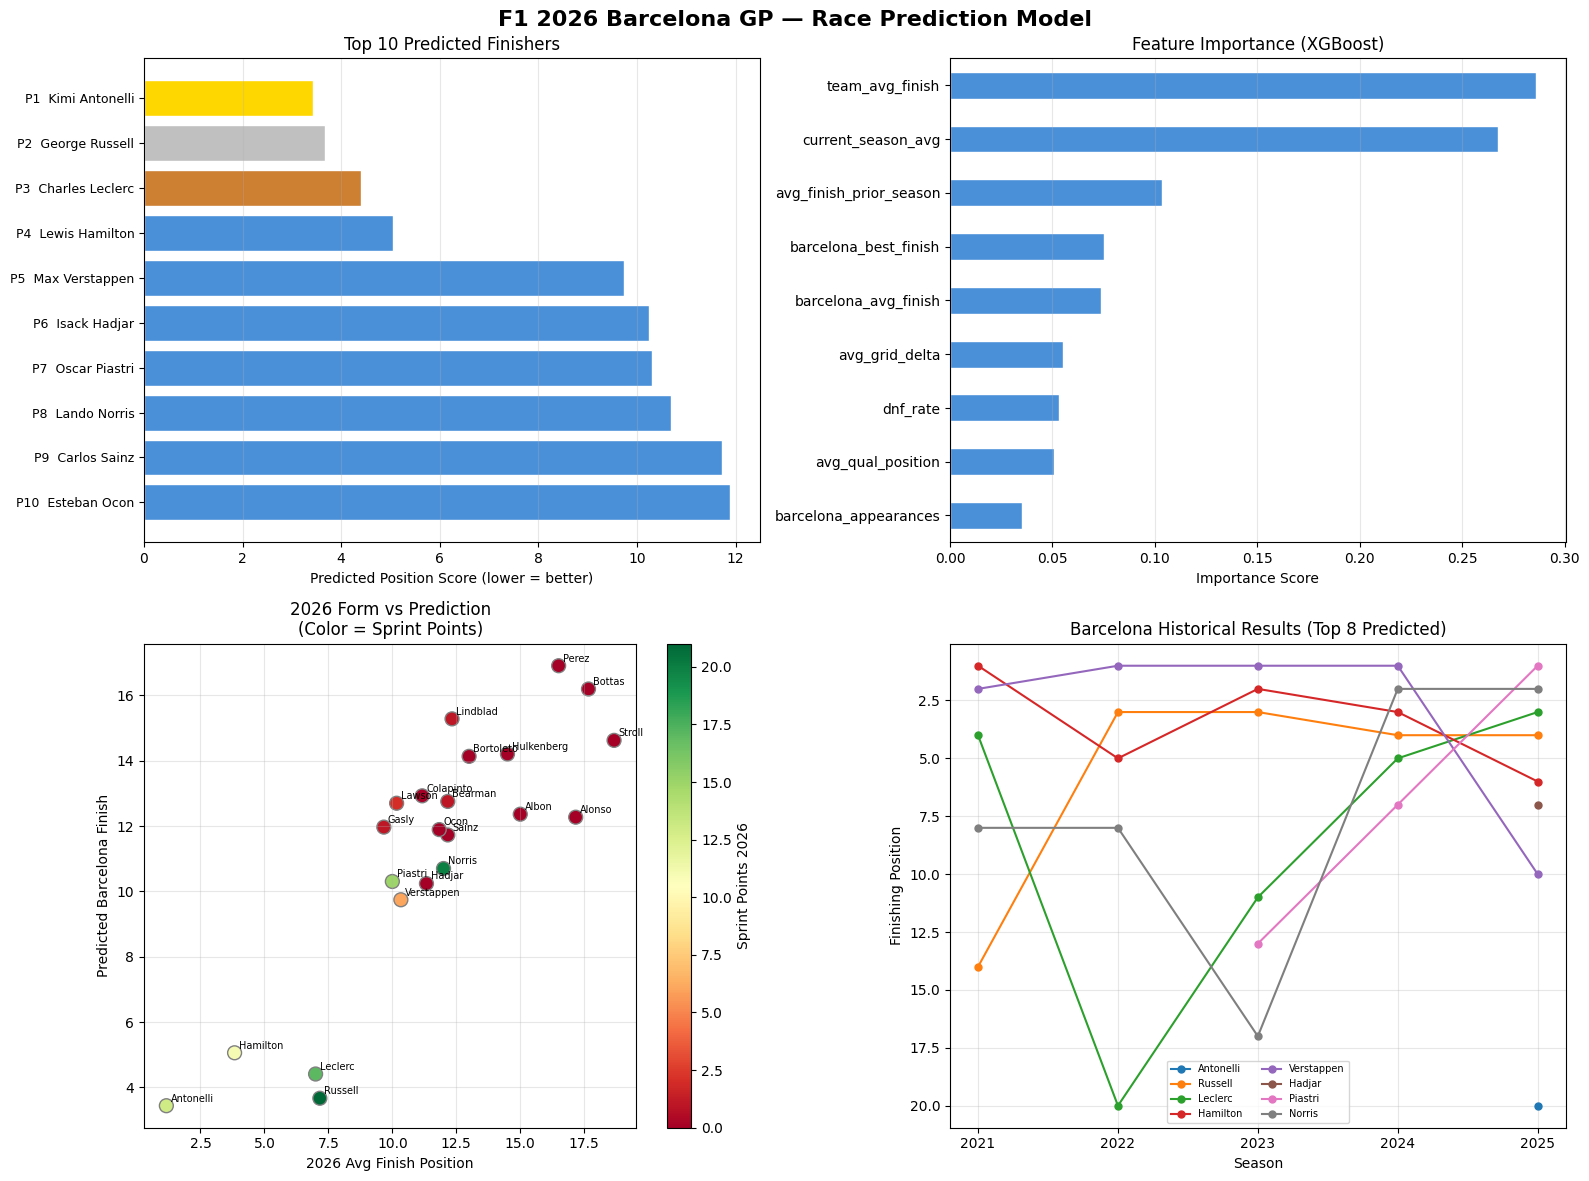

Visualization saved.


In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('F1 2026 Barcelona GP — Race Prediction Model', fontsize=16, fontweight='bold')

# Plot 1: Predicted Finishing Order (Top 10)
ax1 = axes[0, 0]
top10 = results.head(10)
colors = ['gold', 'silver', '#cd7f32'] + ['#4a90d9'] * 7
ax1.barh(range(len(top10)), top10['predicted_position'], color=colors, edgecolor='white')
ax1.set_yticks(range(len(top10)))
ax1.set_yticklabels([f"P{i+1}  {d}" for i, d in enumerate(top10['Driver'])], fontsize=9)
ax1.invert_yaxis()
ax1.set_xlabel('Predicted Position Score (lower = better)')
ax1.set_title('Top 10 Predicted Finishers')
ax1.grid(axis='x', alpha=0.3)

# Plot 2: Feature Importance
ax2 = axes[0, 1]
feat_imp = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=True)
feat_imp.plot(kind='barh', ax=ax2, color='#4a90d9', edgecolor='white')
ax2.set_title('Feature Importance (XGBoost)')
ax2.set_xlabel('Importance Score')
ax2.grid(axis='x', alpha=0.3)

# Plot 3: 2026 Form vs Prediction
ax3 = axes[1, 0]
sc = ax3.scatter(results['avg_finish_2026'], results['predicted_position'],
                 c=results['sprint_points_2026'], cmap='RdYlGn', s=100, edgecolors='gray')
for _, row in results.iterrows():
    ax3.annotate(row['Driver'].split()[-1], (row['avg_finish_2026'], row['predicted_position']),
                 fontsize=7, xytext=(3,3), textcoords='offset points')
plt.colorbar(sc, ax=ax3, label='Sprint Points 2026')
ax3.set_xlabel('2026 Avg Finish Position')
ax3.set_ylabel('Predicted Barcelona Finish')
ax3.set_title('2026 Form vs Prediction\n(Color = Sprint Points)')
ax3.grid(alpha=0.3)

# Plot 4: Barcelona History (Top 8 drivers)
ax4 = axes[1, 1]
top_drivers = results.head(8)['Driver'].tolist()
for driver in top_drivers:
    d = barcelona_races[barcelona_races['Driver'] == driver].sort_values('Season')
    if len(d) > 0:
        ax4.plot(d['Season'], d['Position_Clean'], marker='o', label=driver.split()[-1], linewidth=1.5, markersize=5)
ax4.invert_yaxis()
ax4.set_xlabel('Season')
ax4.set_ylabel('Finishing Position')
ax4.set_title('Barcelona Historical Results (Top 8 Predicted)')
ax4.legend(fontsize=7, ncol=2)
ax4.grid(alpha=0.3)
ax4.set_xticks([2021, 2022, 2023, 2024, 2025])

plt.tight_layout()
plt.savefig('barcelona_2026_prediction.png', dpi=150, bbox_inches='tight')
plt.show()
print("Visualization saved.")


## Section 9: Model Evaluation & Limitations

In [12]:
print("MODEL EVALUATION")
print("="*50)
print(f"Training data : 2021–2025 Barcelona (99 entries)")
print(f"XGBoost CV MAE: {-cv_xgb.mean():.2f} positions (±{cv_xgb.std():.2f})")
print(f"RF CV MAE     : {-cv_rf.mean():.2f} positions (±{cv_rf.std():.2f})")
print(f"Final model   : Ensemble (XGB + RF average)")
print()
print("Top 3 most important features:")
top_feats = pd.Series(xgb.feature_importances_, index=FEATURE_COLS).sort_values(ascending=False).head(3)
for feat, imp in top_feats.items():
    print(f"  {feat}: {imp:.3f}")

print()
print("LIMITATIONS")
print("="*50)
print("1. Only 5 Barcelona data points per driver (one per year)")
print("2. 2026 had significant regulation changes — historical data less relevant")
print("3. No lap time, tire strategy, or weather data")
print("4. New drivers (Antonelli, Lindblad) have no Barcelona history — defaulted to P15")
print("5. DNF/safety car events are unpredictable and not modelled")

# Save CSV
results.to_csv('barcelona_2026_predictions.csv')
print("\nPredictions saved to barcelona_2026_predictions.csv")


MODEL EVALUATION
Training data : 2021–2025 Barcelona (99 entries)
XGBoost CV MAE: 4.03 positions (±0.28)
RF CV MAE     : 3.65 positions (±0.37)
Final model   : Ensemble (XGB + RF average)

Top 3 most important features:
  team_avg_finish: 0.286
  current_season_avg: 0.267
  avg_finish_prior_season: 0.104

LIMITATIONS
1. Only 5 Barcelona data points per driver (one per year)
2. 2026 had significant regulation changes — historical data less relevant
3. No lap time, tire strategy, or weather data
4. New drivers (Antonelli, Lindblad) have no Barcelona history — defaulted to P15
5. DNF/safety car events are unpredictable and not modelled

Predictions saved to barcelona_2026_predictions.csv
